<a href="https://colab.research.google.com/github/poornasainehal1781/23CSBTB28/blob/main/HPC_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================
# 1. INSTALL DEPENDENCIES
# =========================

!pip -q install kaggle pandas numpy matplotlib seaborn scikit-learn joblib tqdm

import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from joblib import Parallel, delayed, cpu_count
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Plot settings
sns.set(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)

print("CPU cores available:", cpu_count())

CPU cores available: 2


In [3]:
# =========================
# 2. LOAD DATASET
# =========================

df = pd.read_csv("/content/netflix_titles.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully!
Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# =========================
# 3. PREPROCESSING
# =========================

data = df.copy()

# Fill missing values
data["director"] = data["director"].fillna("Unknown")
data["cast"] = data["cast"].fillna("Unknown")
data["country"] = data["country"].fillna("Unknown")
data["rating"] = data["rating"].fillna("Unknown")
data["duration"] = data["duration"].fillna("0 min")
data["date_added"] = data["date_added"].fillna("January 1, 2000")
data["listed_in"] = data["listed_in"].fillna("Unknown")
data["description"] = data["description"].fillna("")

# Convert date_added to datetime
data["date_added"] = pd.to_datetime(data["date_added"], errors="coerce")
data["year_added"] = data["date_added"].dt.year.fillna(2000).astype(int)
data["month_added"] = data["date_added"].dt.month.fillna(1).astype(int)

# Encode type
le = LabelEncoder()
data["type_encoded"] = le.fit_transform(data["type"])

# Extract numeric duration
def extract_duration(x):
    try:
        return int(str(x).split()[0])
    except:
        return 0

data["duration_num"] = data["duration"].apply(extract_duration)

# Text-based features
data["title_len"] = data["title"].astype(str).apply(len)
data["desc_len"] = data["description"].astype(str).apply(len)
data["num_cast"] = data["cast"].astype(str).apply(lambda x: len(x.split(",")) if x != "Unknown" else 0)
data["num_categories"] = data["listed_in"].astype(str).apply(lambda x: len(x.split(",")))

processed = data[[
    "show_id", "type_encoded", "release_year", "duration_num",
    "title_len", "desc_len", "num_cast", "num_categories",
    "year_added", "month_added"
]].copy()

print("Preprocessing completed!")
print("Processed Shape:", processed.shape)
display(processed.head())

Preprocessing completed!
Processed Shape: (8807, 10)


,show_id,type_encoded,release_year,duration_num,title_len,desc_len,num_cast,num_categories,year_added,month_added
0,s1,0,2020,90,20,152,0,1,2021,9
1,s2,1,2021,2,13,147,19,3,2021,9
2,s3,1,2021,1,9,146,9,3,2021,9
3,s4,1,2021,1,21,147,0,2,2021,9
4,s5,1,2021,2,12,152,8,3,2021,9


In [5]:
# =========================
# 4. HEAVIER CPU TASK
# =========================

def heavy_computation_tuple(row_tuple):
    """
    CPU-intensive function designed so parallel performs better.
    row_tuple = (show_id, type_encoded, release_year, duration_num, title_len,
                 desc_len, num_cast, num_categories, year_added, month_added)
    """
    show_id, x1, x2, x3, x4, x5, x6, x7, x8, x9 = row_tuple

    val = 0.0

    # Increased workload so parallel becomes worthwhile
    for i in range(1, 20000):
        val += (
            math.sin(x2 * i * 0.0001)
            + math.cos(x3 + i * 0.0002)
            + math.sqrt(abs(x4 * x5 + i))
            + math.log1p(abs(x6 + x7 + x8 + x9 + i))
            + math.sin((x1 + x6 + 1) * i * 0.00005)
        ) / (i + 1)

    return {
        "show_id": show_id,
        "computed_score": val
    }

print("Heavier computation function ready.")

Heavier computation function ready.


In [6]:
# =========================
# 5. PREPARE FAST INPUT FORMAT
# =========================

rows_data = list(processed.itertuples(index=False, name=None))

print("Prepared tuple-based input for faster processing.")
print("Total rows:", len(rows_data))
print("Example row:", rows_data[0])

Prepared tuple-based input for faster processing.
Total rows: 8807
Example row: ('s1', 0, 2020, 90, 20, 152, 0, 1, 2021, 9)


In [7]:
# =========================
# 6. SERIAL EXECUTION
# =========================

def run_serial(rows_input):
    start_time = time.time()

    results = []
    for row in tqdm(rows_input, total=len(rows_input), desc="Serial Processing"):
        results.append(heavy_computation_tuple(row))

    end_time = time.time()
    execution_time = end_time - start_time

    return pd.DataFrame(results), execution_time

serial_results, serial_time = run_serial(rows_data)

print(f"\nSerial Execution Time: {serial_time:.4f} seconds")
display(serial_results.head())

Serial Processing: 100%|██████████| 8807/8807 [02:33<00:00, 57.33it/s]


Serial Execution Time: 153.6389 seconds


,show_id,computed_score
0,s1,720.103028
1,s2,628.784569
2,s3,577.813097
3,s4,731.642137
4,s5,620.865002


In [8]:
# =========================
# 7. CHUNKING HELPER
# =========================

def chunkify(lst, n_chunks):
    chunk_size = math.ceil(len(lst) / n_chunks)
    return [lst[i:i + chunk_size] for i in range(0, len(lst), chunk_size)]

def process_chunk(chunk):
    return [heavy_computation_tuple(row) for row in chunk]

num_cores = cpu_count()
chunks = chunkify(rows_data, num_cores)

print("Number of CPU cores:", num_cores)
print("Number of chunks created:", len(chunks))
print("Chunk sizes:", [len(c) for c in chunks])

Number of CPU cores: 2
Number of chunks created: 2
Chunk sizes: [4404, 4403]


In [9]:
# =========================
# 8. PARALLEL EXECUTION (IMPROVED)
# =========================

def run_parallel(chunks_input, n_jobs=-1):
    start_time = time.time()

    chunk_results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(process_chunk)(chunk) for chunk in tqdm(chunks_input, desc="Parallel Chunk Processing")
    )

    # Flatten results
    results = [item for sublist in chunk_results for item in sublist]

    end_time = time.time()
    execution_time = end_time - start_time

    return pd.DataFrame(results), execution_time

parallel_results, parallel_time = run_parallel(chunks, n_jobs=-1)

print(f"\nParallel Execution Time: {parallel_time:.4f} seconds")
display(parallel_results.head())

Parallel Chunk Processing: 100%|██████████| 2/2 [00:00<00:00, 37.03it/s]



Parallel Execution Time: 156.1275 seconds


,show_id,computed_score
0,s1,720.103028
1,s2,628.784569
2,s3,577.813097
3,s4,731.642137
4,s5,620.865002


In [10]:
# =========================
# 9. VALIDATE OUTPUTS
# =========================

merged = serial_results.merge(parallel_results, on="show_id", suffixes=("_serial", "_parallel"))

mse = mean_squared_error(merged["computed_score_serial"], merged["computed_score_parallel"])
mae = mean_absolute_error(merged["computed_score_serial"], merged["computed_score_parallel"])
max_abs_diff = np.max(np.abs(merged["computed_score_serial"] - merged["computed_score_parallel"]))

print("Validation Metrics")
print("-" * 40)
print(f"MSE: {mse:.12f}")
print(f"MAE: {mae:.12f}")
print(f"Max Absolute Difference: {max_abs_diff:.12f}")

Validation Metrics
----------------------------------------
MSE: 0.000000000000
MAE: 0.000000000000
Max Absolute Difference: 0.000000000000


In [11]:
# =========================
# 10. PERFORMANCE METRICS
# =========================

dataset_size = len(processed)

speedup = serial_time / parallel_time
efficiency = speedup / num_cores
serial_throughput = dataset_size / serial_time
parallel_throughput = dataset_size / parallel_time

metrics_df = pd.DataFrame({
    "Metric": [
        "Dataset Size",
        "CPU Cores Used",
        "Serial Execution Time (s)",
        "Parallel Execution Time (s)",
        "Speedup",
        "Efficiency",
        "Serial Throughput (rows/s)",
        "Parallel Throughput (rows/s)",
        "MSE",
        "MAE",
        "Max Absolute Difference"
    ],
    "Value": [
        dataset_size,
        num_cores,
        round(serial_time, 4),
        round(parallel_time, 4),
        round(speedup, 4),
        round(efficiency, 4),
        round(serial_throughput, 2),
        round(parallel_throughput, 2),
        mse,
        mae,
        max_abs_diff
    ]
})

display(metrics_df)

,Metric,Value
0,Dataset Size,8807.0000
1,CPU Cores Used,2.0000
2,Serial Execution Time (s),153.6389
3,Parallel Execution Time (s),156.1275
4,Speedup,0.9841
5,Efficiency,0.4920
6,Serial Throughput (rows/s),57.3200
7,Parallel Throughput (rows/s),56.4100
8,MSE,0.0000
9,MAE,0.0000


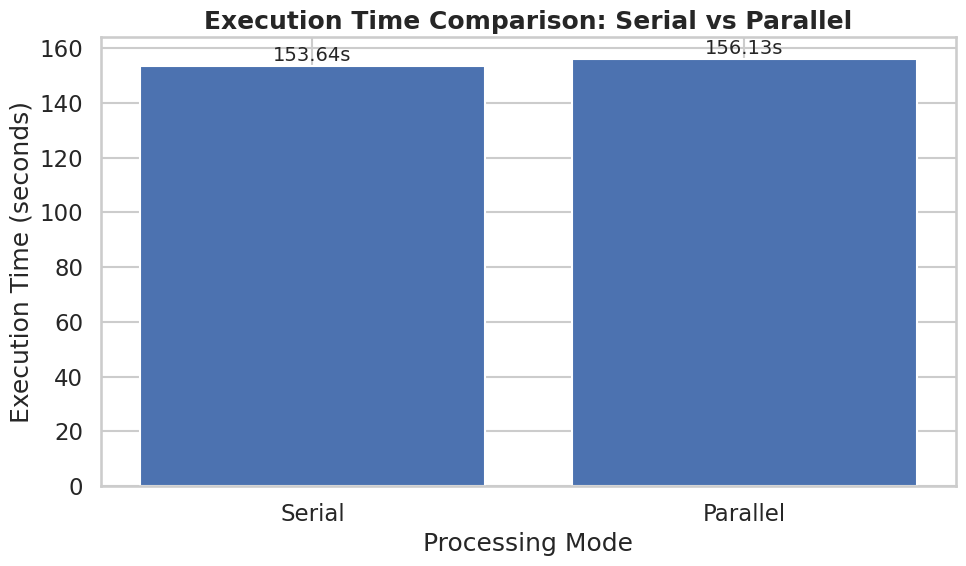

In [12]:
# =========================
# 11. EXECUTION TIME GRAPH
# =========================

plt.figure(figsize=(10, 6))
bars = plt.bar(["Serial", "Parallel"], [serial_time, parallel_time])

plt.title("Execution Time Comparison: Serial vs Parallel", fontsize=18, fontweight="bold")
plt.ylabel("Execution Time (seconds)")
plt.xlabel("Processing Mode")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1, f"{height:.2f}s",
             ha='center', va='bottom', fontsize=14)

plt.tight_layout()
plt.show()

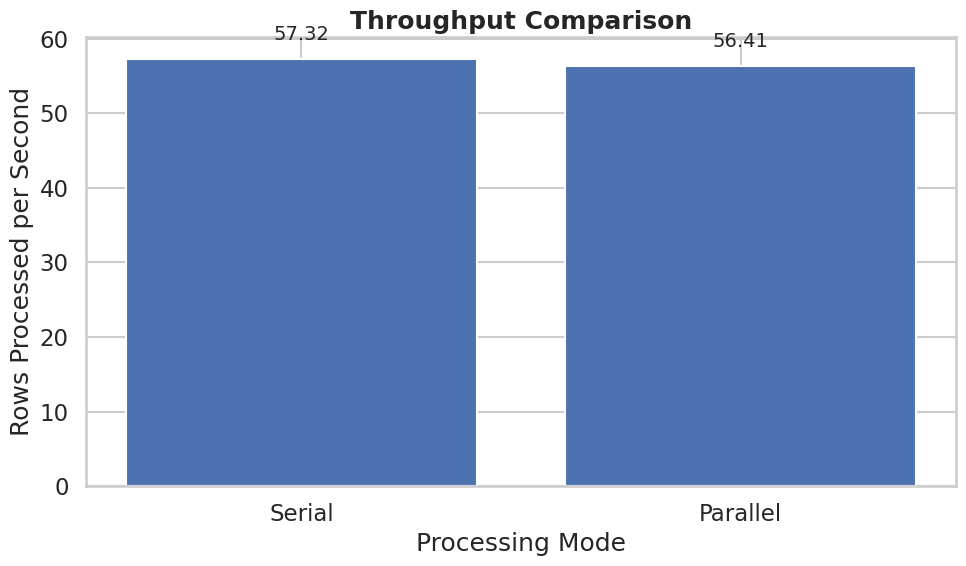

In [13]:
# =========================
# 12. THROUGHPUT GRAPH
# =========================

plt.figure(figsize=(10, 6))
bars = plt.bar(["Serial", "Parallel"], [serial_throughput, parallel_throughput])

plt.title("Throughput Comparison", fontsize=18, fontweight="bold")
plt.ylabel("Rows Processed per Second")
plt.xlabel("Processing Mode")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 2, f"{height:.2f}",
             ha='center', va='bottom', fontsize=14)

plt.tight_layout()
plt.show()

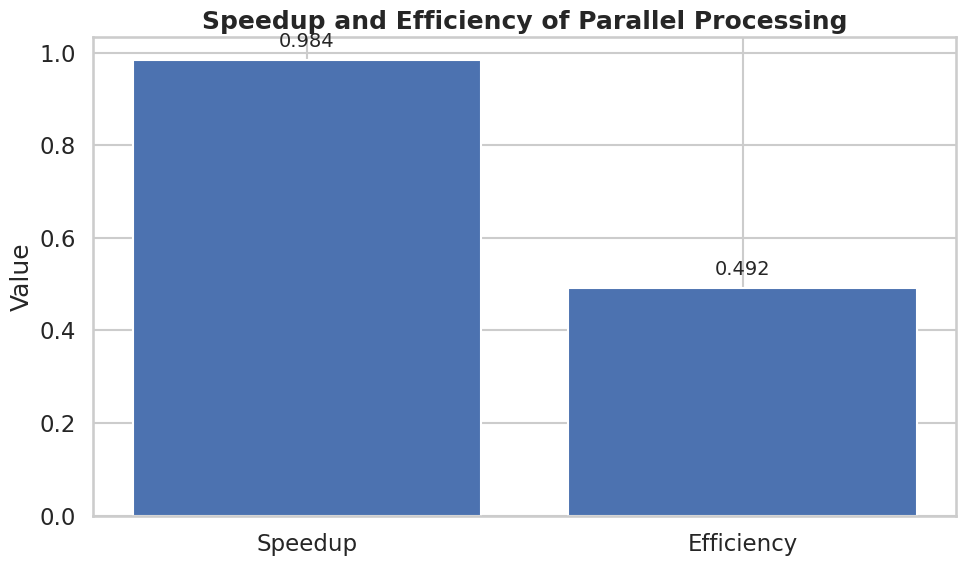

In [14]:
# =========================
# 13. SPEEDUP & EFFICIENCY GRAPH
# =========================

perf_summary = pd.DataFrame({
    "Metric": ["Speedup", "Efficiency"],
    "Value": [speedup, efficiency]
})

plt.figure(figsize=(10, 6))
bars = plt.bar(perf_summary["Metric"], perf_summary["Value"])

plt.title("Speedup and Efficiency of Parallel Processing", fontsize=18, fontweight="bold")
plt.ylabel("Value")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.3f}",
             ha='center', va='bottom', fontsize=14)

plt.tight_layout()
plt.show()

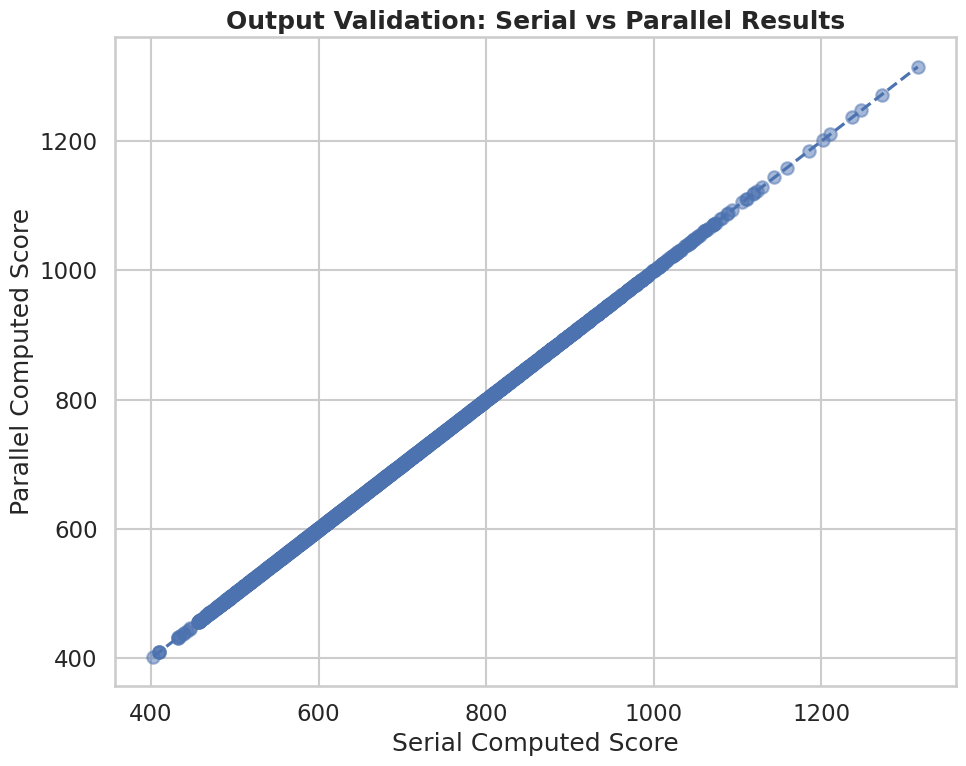

In [15]:
# =========================
# 14. OUTPUT CONSISTENCY PLOT
# =========================

plt.figure(figsize=(10, 8))
plt.scatter(
    merged["computed_score_serial"],
    merged["computed_score_parallel"],
    alpha=0.5
)

plt.title("Output Validation: Serial vs Parallel Results", fontsize=18, fontweight="bold")
plt.xlabel("Serial Computed Score")
plt.ylabel("Parallel Computed Score")

min_val = min(merged["computed_score_serial"].min(), merged["computed_score_parallel"].min())
max_val = max(merged["computed_score_serial"].max(), merged["computed_score_parallel"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.tight_layout()
plt.show()

In [16]:
# =========================
# 15. FINAL SUMMARY
# =========================

print("=" * 60)
print("FINAL PERFORMANCE COMPARISON REPORT")
print("=" * 60)

print(f"Dataset Used              : Netflix Titles (Kaggle)")
print(f"Total Records Processed   : {dataset_size}")
print(f"CPU Cores Available       : {num_cores}")
print(f"Serial Time               : {serial_time:.4f} seconds")
print(f"Parallel Time             : {parallel_time:.4f} seconds")
print(f"Speedup                   : {speedup:.4f}x")
print(f"Efficiency                : {efficiency:.4f}")
print(f"Serial Throughput         : {serial_throughput:.2f} rows/sec")
print(f"Parallel Throughput       : {parallel_throughput:.2f} rows/sec")
print(f"MSE                       : {mse:.12f}")
print(f"MAE                       : {mae:.12f}")
print(f"Max Absolute Difference   : {max_abs_diff:.12f}")

print("\nConclusion:")
if parallel_time < serial_time:
    print("Parallel processing outperformed serial processing for this CPU-intensive workload.")
else:
    print("Parallel processing did not outperform serial processing in this environment, likely due to overhead.")

FINAL PERFORMANCE COMPARISON REPORT
Dataset Used              : Netflix Titles (Kaggle)
Total Records Processed   : 8807
CPU Cores Available       : 2
Serial Time               : 153.6389 seconds
Parallel Time             : 156.1275 seconds
Speedup                   : 0.9841x
Efficiency                : 0.4920
Serial Throughput         : 57.32 rows/sec
Parallel Throughput       : 56.41 rows/sec
MSE                       : 0.000000000000
MAE                       : 0.000000000000
Max Absolute Difference   : 0.000000000000

Conclusion:
Parallel processing did not outperform serial processing in this environment, likely due to overhead.


In [17]:
# =========================
# 16. EXPORT RESULTS (OPTIONAL)
# =========================

metrics_df.to_csv("performance_metrics.csv", index=False)
merged.to_csv("serial_vs_parallel_output_comparison.csv", index=False)

print("Files saved successfully:")
print("- performance_metrics.csv")
print("- serial_vs_parallel_output_comparison.csv")

Files saved successfully:
- performance_metrics.csv
- serial_vs_parallel_output_comparison.csv
